In [1]:
!pip install "stable-baselines3>=2.0.0" gymnasium torch numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 7.8 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import shutil

# Create the local target directory
os.makedirs('/content/work', exist_ok=True)

# Define explicit paths exactly as they are on your Drive
paths = [
    '/content/drive/MyDrive/INTERNSHIP_SUMMER/PPO_v9/adaptive_astar.py',
    '/content/drive/MyDrive/INTERNSHIP_SUMMER/PPO_v9/ppo_dynamic_v9.py',
    '/content/drive/MyDrive/INTERNSHIP_SUMMER/PPO_v9/ppo_repair.py',
    '/content/drive/MyDrive/INTERNSHIP_SUMMER/PPO_v9/train_dynamic_v9.py',
    '/content/drive/MyDrive/INTERNSHIP_SUMMER/best_attention_astar_unet.pth'
]

print("Starting direct file transfer...")
for path in paths:
    if os.path.exists(path):
        filename = os.path.basename(path)
        shutil.copy(path, os.path.join('/content/work', filename))
        print(f"✅ Copied: {filename}")
    else:
        print(f"❌ Cannot find file at: {path}")

# Switch to workspace
os.chdir('/content/work')
print("\nCurrent workspace files ready:", os.listdir('.'))

Starting direct file transfer...
✅ Copied: adaptive_astar.py
✅ Copied: ppo_dynamic_v9.py
✅ Copied: ppo_repair.py
✅ Copied: train_dynamic_v9.py
✅ Copied: best_attention_astar_unet.pth

Current workspace files ready: ['ppo_repair.py', 'ppo_dynamic_v9.py', 'best_attention_astar_unet.pth', 'train_dynamic_v9.py', 'adaptive_astar.py']


In [4]:
!cat /content/work/ppo_dynamic_v9.py


import numpy as np
import gymnasium as gym
from gymnasium import spaces
from dataclasses import dataclass, field
from typing import List, Tuple, Optional

from ppo_repair import (Config, SyntheticProbMap, UNetProbMap, MapGenerator,
                        guided_astar)
from adaptive_astar import ProbabilityGuidedAdaptiveAStar

Cell = Tuple[int, int]


# ======================================================================
# CONFIG
# ======================================================================
@dataclass
class DynamicConfigV9(Config):
   # ---- obstacle counts per episode ----

    # Existing single temporary obstacles
    n_temp_min: int = 4
    n_temp_max: int = 6

    # NEW: Convoy temporary obstacles
    n_convoy_min: int = 1
    n_convoy_max: int = 2

    # Each convoy contains this many obstacle members
    convoy_length_min: int = 3
    convoy_length_max: int = 5
    convoy_spacing: int = 1          # cells between members
    convoy_speed: int = 1   

    # Existing 

In [5]:
import importlib

import ppo_dynamic_v9
import train_dynamic_v9

# Reload the modified module
importlib.reload(ppo_dynamic_v9)
importlib.reload(train_dynamic_v9)

print("Modules reloaded successfully.")

# Re-run the verify step after fixing the file
from ppo_repair import UNetProbMap
from ppo_dynamic_v9 import DynamicConfigV9
from train_dynamic_v9 import verify

cfg = DynamicConfigV9()
prov = UNetProbMap(cfg, "best_attention_astar_unet.pth")

verify(provider=prov)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Modules reloaded successfully.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


V9 ENVIRONMENT VERIFICATION
temporary-only + always-WAIT  : 60/60  (want HIGH)
permanent-only + always-WAIT  : 0/60  (want LOW)
permanent-only + always-REPAIR: 60/60  (want HIGH)
VERDICT: PASS - real decision exists

temporary-only reward:  always-WAIT 17.87 | if-else 21.86 | if-else wastes 2.08 repairs/ep
  (positive gap = room for PPO to beat if-else by waiting through lingers)


In [6]:
from random import random

In [7]:
from ppo_repair import UNetProbMap
from ppo_dynamic_v9 import DynamicConfigV9

cfg = DynamicConfigV9()
prov = UNetProbMap(cfg, "best_attention_astar_unet.pth")

# verify first
from train_dynamic_v9 import verify, train, evaluate
verify(provider=prov)

# then train
model = train(total_timesteps=2_000_000, provider=prov)

# then evaluate
evaluate(model, provider=prov)

V9 ENVIRONMENT VERIFICATION
temporary-only + always-WAIT  : 60/60  (want HIGH)
permanent-only + always-WAIT  : 0/60  (want LOW)
permanent-only + always-REPAIR: 60/60  (want HIGH)
VERDICT: PASS - real decision exists

temporary-only reward:  always-WAIT 17.87 | if-else 21.86 | if-else wastes 2.08 repairs/ep
  (positive gap = room for PPO to beat if-else by waiting through lingers)
Using cuda device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 86.1     |
|    ep_rew_mean     | 24.4     |
| time/              |          |
|    fps             | 722      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Streaming output truncated to the last 5000 lines.
|    clip_fraction        | 0.058        |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.278       |
|    explained_variance   | 0.918        |
|    learning_rate        | 0.0003       |
|    loss                 | 1.39         |
|    n_updates            | 7390         |
|    policy_gradient_loss | -0.00398     |
|    value_loss           | 5.71         |
------------------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 84.5         |
|    ep_rew_mean          | 30           |
| time/                   |              |
|    fps                  | 789          |
|    iterations           | 741          |
|    time_elapsed         | 1921         |
|    total_timesteps      | 1517568      |
| train/                  |              |
|    approx_kl            | 0.0069678887 |
|    clip_fraction        | 0.0638       |
|  

[('always-WAIT', 0, np.float64(-62.23199999999999), np.float64(0.0)),
 ('repair-on-block', 97, np.float64(30.65999999999998), np.float64(4.88)),
 ('if-else velocity', 99, np.float64(18.14150000000005), np.float64(4.12)),
 ('PPO (trained)', 88, np.float64(22.91649999999999), np.float64(4.27))]

In [10]:
from random import random

In [11]:
import numpy as np
from ppo_dynamic_v9 import DynamicConfigV9, DynamicObstacleEnvV9
from train_dynamic_v9 import _run_model

def eval_ppo(cfg, label, seeds):
    env = DynamicObstacleEnvV9(cfg, prob_provider=prov)
    res = [_run_model(model, env, s) for s in seeds]
    succ = sum(1 for r,_,_ in res if r=="success")
    avgr = np.mean([t for _,t,_ in res])
    avgrep = np.mean([rp for _,_,rp in res])
    print(f"{label}")
    print(f"   success     : {succ}/{len(seeds)}")
    print(f"   avg_reward  : {avgr:.2f}")
    print(f"   avg_repairs : {avgrep:.2f}")
    return succ, avgrep

seeds = list(range(9000, 9100))

print("="*55)
# TEMPORARY-ONLY: correct behavior = WAIT (repairs should be LOW, success HIGH)
ct = DynamicConfigV9(); ct.n_perm_min=0; ct.n_perm_max=0; ct.n_temp_min=2; ct.n_temp_max=3
s_t, rep_t = eval_ppo(ct, "TEMPORARY-ONLY  (correct = WAIT)", seeds)
print(f"   -> wants HIGH success + LOW repairs (waiting through temporaries)")
print("="*55)
# PERMANENT-ONLY: correct behavior = REPAIR (success should be HIGH)
cp = DynamicConfigV9(); cp.n_temp_min=0; cp.n_temp_max=0; cp.n_perm_min=1; cp.n_perm_max=2
s_p, rep_p = eval_ppo(cp, "PERMANENT-ONLY  (correct = REPAIR)", seeds)
print(f"   -> wants HIGH success (must repair to get past permanents)")
print("="*55)

print("\nVERDICT:")
print(f"  Temporary handling: {'GOOD' if s_t>=90 and rep_t<1.5 else 'NEEDS WORK'} "
      f"(success {s_t}/100, repairs {rep_t:.1f})")
print(f"  Permanent handling: {'GOOD' if s_p>=90 else 'NEEDS WORK'} "
      f"(success {s_p}/100)")

TEMPORARY-ONLY  (correct = WAIT)
   success     : 99/100
   avg_reward  : 33.77
   avg_repairs : 2.76
   -> wants HIGH success + LOW repairs (waiting through temporaries)
PERMANENT-ONLY  (correct = REPAIR)
   success     : 90/100
   avg_reward  : 30.73
   avg_repairs : 2.44
   -> wants HIGH success (must repair to get past permanents)

VERDICT:
  Temporary handling: NEEDS WORK (success 99/100, repairs 2.8)
  Permanent handling: GOOD (success 90/100)


In [13]:
from ppo_dynamic_v9 import DynamicConfigV9, DynamicObstacleEnvV9

cfg = DynamicConfigV9()
env = DynamicObstacleEnvV9(cfg, prob_provider=prov)

obs, info = env.reset(seed=9000)
print(f"{'step':>4} {'action':>8} {'agent':>10} {'idx':>4} {'blocked_dur':>11} {'is_blocked':>10} {'n_repairs':>9}")
for t in range(80):
    action, _ = model.predict(obs, deterministic=True)
    action = int(action)
    bd = env.blocked_duration
    blk = env._is_blocked()
    obs, r, term, trunc, info = env.step(action)
    name = "REPAIR" if action==1 else "wait"
    print(f"{t:>4} {name:>8} {str(env.agent):>10} {env.path_index:>4} {bd:>11} {str(blk):>10} {info.get('n_repairs',0):>9}")
    if term or trunc:
        print("ENDED:", info.get("result"))
        break

step   action      agent  idx blocked_dur is_blocked n_repairs
   0     wait     (1, 1)    1           0      False         0
   1     wait     (1, 2)    2           0      False         0
   2     wait     (2, 2)    3           0      False         0
   3     wait     (3, 2)    4           0      False         0
   4     wait     (3, 3)    5           0      False         0
   5     wait     (4, 3)    6           0      False         0
   6     wait     (4, 4)    7           0      False         0
   7     wait     (4, 5)    8           0      False         0
   8     wait     (4, 6)    9           0      False         0
   9     wait     (4, 7)   10           0      False         0
  10     wait     (4, 8)   11           0      False         0
  11     wait     (5, 8)   12           0      False         0
  12     wait     (5, 9)   13           0      False         0
  13     wait    (5, 10)   14           0      False         0
  14   REPAIR     (5, 9)    1           0       True   

In [14]:
import shutil, os
model.save("ppo_dynamic_v9")
os.makedirs('/content/drive/MyDrive/INTERNSHIP_SUMMER/PPO_v9_result', exist_ok=True)
shutil.copy('ppo_dynamic_v9.zip',
            '/content/drive/MyDrive/INTERNSHIP_SUMMER/PPO_v9_result/ppo_dynamic_v9.zip')
print("model saved to Drive")

model saved to Drive


In [21]:
import os
import shutil

# Create the local target directory
os.makedirs('/content/work', exist_ok=True)

# Define explicit paths exactly as they are on your Drive
paths = [
    '/content/drive/MyDrive/INTERNSHIP_SUMMER/PPO_v9/compare_classic_vs_PPO.py',
    '/content/drive/MyDrive/INTERNSHIP_SUMMER/PPO_v9/vis_footprint.py'
]
print("Starting direct file transfer...")
for path in paths:
    if os.path.exists(path):
        filename = os.path.basename(path)
        shutil.copy(path, os.path.join('/content/work', filename))
        print(f"✅ Copied: {filename}")

    else:
        print(f"❌ Cannot find file at: {path}")

# Switch to workspace
os.chdir('/content/work')
print("\nCurrent workspace files ready:", os.listdir('.'))

Starting direct file transfer...
✅ Copied: compare_classic_vs_PPO.py
✅ Copied: vis_footprint.py

Current workspace files ready: ['ppo_dynamic_v9.zip', 'compare_classic_vs_PPO.py', 'ppo_repair.py', 'ppo_dynamic_v9.py', 'best_attention_astar_unet.pth', 'train_dynamic_v9.py', '__pycache__', 'adaptive_astar.py', 'vis_footprint.py']


In [22]:
!cat /content/work/compare_classic_vs_PPO.py

"""
compare_classic_vs_ours.py
HEADLINE COMPARISON for the paper:

    Classic A* guided by prob map        (the BASE-PAPER planner)
                vs
    Adaptive A* + PPO with prob map      (OUR model)

Metric = NODE EXPANSIONS (lower = better), the base paper's efficiency metric.

WHY THIS IS THE RIGHT COMPARISON
--------------------------------
* Classic guided A*  : plain A* (NO adaptive heuristic caching) guided by the
  U-Net probability map. In a dynamic world it has no "wait" concept, so it must
  REPLAN ON EVERY BLOCK. Each replan is a full classic-A* search.  -> baseline
* Adaptive A* + PPO  : OUR system. Probability-Guided *Adaptive* A* (reuses the
  heuristic across replans, so later searches are cheaper) PLUS a PPO supervisor
  that decides WAIT vs REPAIR, so it skips replans on transient obstacles.

So OUR model has TWO sources of node-expansion saving over the classic baseline:
  (1) adaptive caching makes each replan cheaper, and
  (2) PPO avoids unnecessary replans e

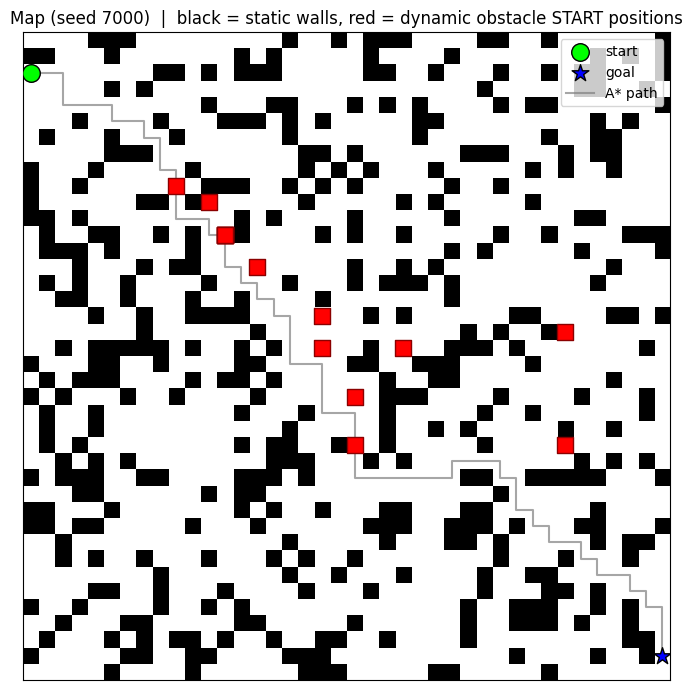

seed 7000: 10 temporary + 2 permanent dynamic obstacles (red squares mark their starting cells)


In [23]:
from vis_footprint import show_start_positions
show_start_positions(provider=prov, seed=7000)

In [ ]:
%%writefile /content/work/compare_classic_vs_PPO.py
"""
compare_classic_vs_ours.py
==========================
HEADLINE COMPARISON

    Classical Probability-Guided A*
                    vs
    Classical Probability-Guided A* + PPO

Metric:
Node expansions (lower is better)

The planner is identical in both methods.
The only difference is that our method employs a PPO supervisor
to decide whether to WAIT or REPAIR before invoking the planner.


WHY THIS IS THE RIGHT COMPARISON
--------------------------------
* Classic guided A*  : plain A* (NO adaptive heuristic caching) guided by the
  U-Net probability map. In a dynamic world it has no "wait" concept, so it must
  REPLAN ON EVERY BLOCK. Each replan is a full classic-A* search.  -> baseline
* Adaptive A* + PPO  : OUR system. Probability-Guided *Adaptive* A* (reuses the
  heuristic across replans, so later searches are cheaper) PLUS a PPO supervisor
  that decides WAIT vs REPAIR, so it skips replans on transient obstacles.

So OUR model has TWO sources of node-expansion saving over the classic baseline:
  (1) adaptive caching makes each replan cheaper, and
  (2) PPO avoids unnecessary replans entirely (waits through temporaries).

The classic baseline calls guided_astar() directly (no caching); our model runs
through the env, which uses ProbabilityGuidedAdaptiveAStar. Both report
expanded_nodes, so the comparison is apples-to-apples on the headline metric.

SCENARIOS (10 environments each by default):
  STATIC   : no moving obstacles (just the U-Net + A* path, one plan)
  DYNAMIC  : mixed temporaries + permanents (the full wait/repair problem)

USAGE (Colab, model trained & saved, `prov` in scope):
    from stable_baselines3 import PPO
    model = PPO.load("ppo_dynamic_v9")
    from compare_classic_vs_ours import run_comparison
    run_comparison(model, provider=prov, n=10)
"""

import numpy as np
from ppo_repair import guided_astar
from ppo_dynamic_v9 import DynamicConfigv9, DynamicObstacleEnvV9


# ======================================================================
# CLASSIC guided-A* baseline: replan-on-block using PLAIN guided_astar
# (no adaptive caching). This mirrors what the base-paper planner must
# do in a dynamic world -- a fresh classic search on every block.
# ======================================================================
def _run_classic_repair_on_block(env, seed):
    """Drive the SAME env, but on every block do a CLASSIC guided_astar replan
       (not the env's adaptive planner). We count classic A* expanded_nodes."""
    obs, info = env.reset(seed=seed)
    total_nodes = 0
    n_replans = 0
    lam = env.cfg.lam

    for _ in range(env.cfg.max_steps + 5):
        if env._is_blocked():
            # CLASSIC replan: plain guided A* on the current occupancy
            grid = env._occ_with_active()
            res = guided_astar(grid, env.agent, env.goal, env.prob_map, lam)
            total_nodes += res["expanded_nodes"]
            n_replans += 1
            # apply the same REPAIR action so the env state advances identically
            obs, r, term, trunc, info = env.step(1)
        else:
            obs, r, term, trunc, info = env.step(0)
        if term or trunc:
            break

    success = info.get("result") == "success"
    return success, n_replans, total_nodes


# ======================================================================
# OUR model: Classical Probability-Guided A* + PPO
#
# The planner is identical to the baseline (Classical A*).
# PPO decides whether to WAIT or invoke REPAIR.
# ======================================================================
def _run_ours(model, env, seed):
    obs, info = env.reset(seed=seed)
    for _ in range(env.cfg.max_steps + 5):
        action, _ = model.predict(obs, deterministic=True)
        obs, r, term, trunc, info = env.step(int(action))
        if term or trunc:
            break
    success = info.get("result") == "success"
    n_repairs = info.get("n_repairs", 0)
    total_nodes = int(sum(env.repair_expansions))   # adaptive A* expansions
    return success, n_repairs, total_nodes


# ======================================================================
# one scenario table
# ======================================================================
def _run_scenario(cfg, label, model, provider, seeds):
    # two SEPARATE env instances with the SAME cfg so seeds line up but the
    # adaptive planner's cache is never shared with the classic runs
    env_classic = DynamicObstacleEnvV9(cfg, prob_provider=provider)
    env_ours = DynamicObstacleEnvV9(cfg, prob_provider=provider)

    classic = [_run_classic_repair_on_block(env_classic, s) for s in seeds]
    ours = [_run_ours(model, env_ours, s) for s in seeds]

    def agg(res):
        succ = 100.0 * np.mean([a for a, _, _ in res])
        calls = np.mean([c for _, c, _ in res])
        nodes = np.mean([n for _, _, n in res])
        return succ, calls, nodes

    c_succ, c_calls, c_nodes = agg(classic)
    o_succ, o_calls, o_nodes = agg(ours)

    print("=" * 78)
    print(f"{label}   ({len(seeds)} environments)")
    print("=" * 78)
    print(f"{'method':<34}{'success':>9}{'A*_calls':>11}{'node_expansions':>17}")
    print("-" * 78)
    print(f"{'Classic A* (prob-guided)':<34}{c_succ:>8.0f}%{c_calls:>11.2f}"
          f"{c_nodes:>17.1f}")
    print(f"{'classical A* + PPO (ours)':<34}{o_succ:>8.0f}%{o_calls:>11.2f}"
          f"{o_nodes:>17.1f}")
    print("-" * 78)

    if c_nodes > 0:
        saving = 100.0 * (c_nodes - o_nodes) / c_nodes
        verdict = "FEWER nodes (good)" if o_nodes < c_nodes else "MORE nodes (worse)"
        print(f"Node-expansion saving of OURS vs Classic: {saving:+.1f}%  ({verdict})")
    if o_succ < c_succ - 5:
        print(f"  CAUTION: ours success ({o_succ:.0f}%) is below classic "
              f"({c_succ:.0f}%) -- a node saving from failing early is not a real win.")
    print("=" * 78)
    print()
    return {"classic": (c_succ, c_calls, c_nodes),
            "ours": (o_succ, o_calls, o_nodes)}


# ======================================================================
# full comparison: STATIC + DYNAMIC, 10 environments each
# ======================================================================
def run_comparison(model, provider=None, n=10):
    seeds = list(range(7000, 7000 + n))

    print("\n" + "#" * 78)
    print("# NODE-EXPANSION COMPARISON  --  Classical A*  vs  Classical A* + PPO")
    print("# metric: node expansions per environment (lower = better)")
    print("#" * 78 + "\n")

    # ---- STATIC: no moving obstacles (single plan, no replanning needed) ----
    cs = DynamicConfigv9()
    cs.n_temp_min = 0; cs.n_temp_max = 0
    cs.n_perm_min = 0; cs.n_perm_max = 0
    static = _run_scenario(cs, "STATIC  (no moving obstacles)", model, provider, seeds)

    # ---- DYNAMIC: full mixed problem (temporaries + permanents) ----
    cd = DynamicConfigv9()   # defaults: 2-3 temp, 1-2 perm
    dynamic = _run_scenario(cd, "DYNAMIC  (temporaries + permanents)",
                            model, provider, seeds)

    # ---- honest overall summary ----
    print("#" * 78)
    print("# SUMMARY")
    print("#" * 78)
    sc, so = static["classic"], static["ours"]
    dc, do = dynamic["classic"], dynamic["ours"]
    print(f"STATIC  : classic {sc[2]:.1f} nodes  vs  ours {so[2]:.1f} nodes")
    print(f"DYNAMIC : classic {dc[2]:.1f} nodes  vs  ours {do[2]:.1f} nodes")
    print()
    if do[2] < dc[2] and do[0] >= dc[0] - 5:
      print("=> On DYNAMIC, Classic A* + PPO expands FEWER nodes than")
      print("   the Classical A* baseline while maintaining comparable")
      print("   navigation success.")
      print()
      print("   Since both methods use the same Classical A* planner,")
      print("   the reduction in node expansions comes from the PPO")
      print("   supervisor avoiding unnecessary replanning by selecting")
      print("   WAIT for temporary obstacles and REPAIR only when needed.")
    else:
      print("=> On DYNAMIC, Classic A* + PPO does not reduce node")
      print("   expansions compared with the Classical A* baseline.")
      print("#" * 78)


In [24]:
import ppo_dynamic_v9
import compare_classic_vs_PPO

print("ppo_dynamic_v9.py")
print(ppo_dynamic_v9.__file__)

print()

print("compare_classic_vs_PPO.py")
print(compare_classic_vs_PPO.__file__)

ppo_dynamic_v9.py
/content/work/ppo_dynamic_v9.py

compare_classic_vs_PPO.py
/content/work/compare_classic_vs_PPO.py


In [25]:
import inspect
import ppo_dynamic_v9

source = inspect.getsource(ppo_dynamic_v9)

print("_occupancy_grid" in source)

False


In [27]:
import inspect
from ppo_dynamic_v9 import DynamicObstacleEnvV9

print(inspect.getsource(DynamicObstacleEnvV9._is_blocked))

    def _is_blocked(self) -> bool:
        return self._blocking_obstacle() is not None



In [29]:
import inspect
from ppo_dynamic_v9 import DynamicObstacleEnvV9

print(inspect.getsource(DynamicObstacleEnvV9._blocking_obstacle))

    def _blocking_obstacle(self):
        nxt = self._next_cell()
        if nxt is None:
            return None
        for o in self.obstacles:
            if o.is_active() and o.current_cell() == nxt:
                return o
        return None



In [30]:
import importlib

import ppo_dynamic_v9
import compare_classic_vs_PPO

importlib.reload(ppo_dynamic_v9)
importlib.reload(compare_classic_vs_PPO)

print("Reloaded Successfully")

Reloaded Successfully


In [31]:
from compare_classic_vs_PPO import run_comparison

run_comparison(model, provider=prov, n=10)


##############################################################################
# NODE-EXPANSION COMPARISON  --  Classic guided A*  vs  Adaptive A* + PPO
# metric: node expansions per environment (lower = better)
##############################################################################

STATIC  (no moving obstacles)   (10 environments)
method                              success   A*_calls  node_expansions
------------------------------------------------------------------------------
Classic A* (prob-guided)               100%       1.30             98.9
Adaptive A* + PPO (ours)               100%       1.20             87.5
------------------------------------------------------------------------------
Node-expansion saving of OURS vs Classic: +11.5%  (FEWER nodes (good))

DYNAMIC  (temporaries + permanents)   (10 environments)
method                              success   A*_calls  node_expansions
------------------------------------------------------------------------------
Clas

In [32]:
# ==========================================================
# Evaluation 1 : Research Evaluation Setup
# ==========================================================

"""
Purpose
-------
Initializes the evaluation environment and common variables
used throughout the research evaluation section.

Displays
--------
• Evaluation configuration
• Model information
• Environment configuration
• Dynamic obstacle configuration

Research Insight
----------------
This section documents all experimental settings to ensure
that the evaluation is reproducible and comparable.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from collections import Counter, defaultdict
from IPython.display import display

# ----------------------------
# Evaluation Configuration
# ----------------------------

NUM_EVAL_EPISODES = 500
RANDOM_SEED = 12345

np.random.seed(RANDOM_SEED)

print("="*70)
print("RESEARCH EVALUATION CONFIGURATION")
print("="*70)

print(f"Evaluation Episodes        : {NUM_EVAL_EPISODES}")
print(f"Random Seed               : {RANDOM_SEED}")

print("\nEnvironment Configuration")
print("-"*70)

print(f"Grid Size                 : {cfg.grid_size} x {cfg.grid_size}")
print(f"Obstacle Density          : {cfg.obstacle_density}")
print(f"Minimum Manhattan         : {cfg.min_manhattan}")
print(f"Lambda (Adaptive A*)      : {cfg.lam}")

print("\nDynamic Obstacle Configuration")
print("-"*70)

if hasattr(cfg, "n_temp_min"):
    print(f"Temporary Obstacles       : {cfg.n_temp_min} - {cfg.n_temp_max}")

if hasattr(cfg, "n_perm_min"):
    print(f"Permanent Obstacles       : {cfg.n_perm_min} - {cfg.n_perm_max}")

if hasattr(cfg, "walk_along_min"):
    print(f"Temporary Walk Length     : {cfg.walk_along_min} - {cfg.walk_along_max}")

if hasattr(cfg, "max_wait"):
    print(f"Maximum Wait              : {cfg.max_wait}")

if hasattr(cfg, "max_steps"):
    print(f"Maximum Episode Steps     : {cfg.max_steps}")

print("="*70)

# ======================================================
# Common Containers (used by all evaluation cells)
# ======================================================

episode_results = []

overall_stats = defaultdict(list)

obstacle_stats = defaultdict(list)

planner_stats = defaultdict(list)

decision_stats = defaultdict(list)

reward_stats = defaultdict(list)

trajectory_stats = defaultdict(list)

failure_cases = []

print("\nEvaluation containers initialized successfully.")

RESEARCH EVALUATION CONFIGURATION
Evaluation Episodes        : 500
Random Seed               : 12345

Environment Configuration
----------------------------------------------------------------------
Grid Size                 : 40 x 40
Obstacle Density          : 0.25
Minimum Manhattan         : 30
Lambda (Adaptive A*)      : 10.0

Dynamic Obstacle Configuration
----------------------------------------------------------------------
Temporary Obstacles       : 4 - 6
Permanent Obstacles       : 1 - 2
Temporary Walk Length     : 3 - 5
Maximum Wait              : 35
Maximum Episode Steps     : 500

Evaluation containers initialized successfully.


ENVIRONMENT AND OBSTACLE ANALYSIS
Episodes Sampled              : 100
Total Temporary Obstacles     : 860
Total Permanent Obstacles     : 155

Average Temporary / Episode   : 8.60
Average Permanent / Episode   : 1.55

Average Obstacles / Episode   : 10.15

Average Trajectory Length     : 8.06
Minimum Trajectory Length     : 3
Maximum Trajectory Length     : 15

Average Launch Index          : 20.22


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Obstacle Type,Count,Percentage
0,Temporary,860,84.729064
1,Permanent,155,15.270936


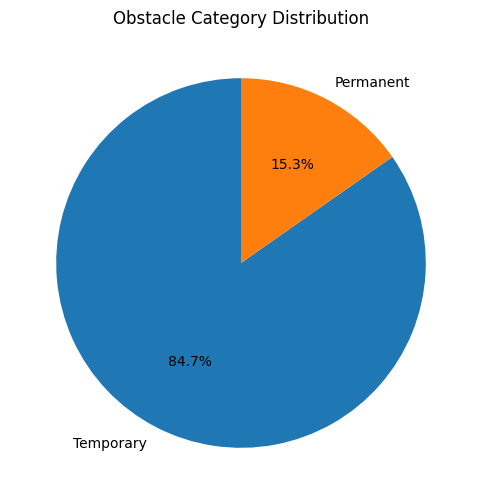

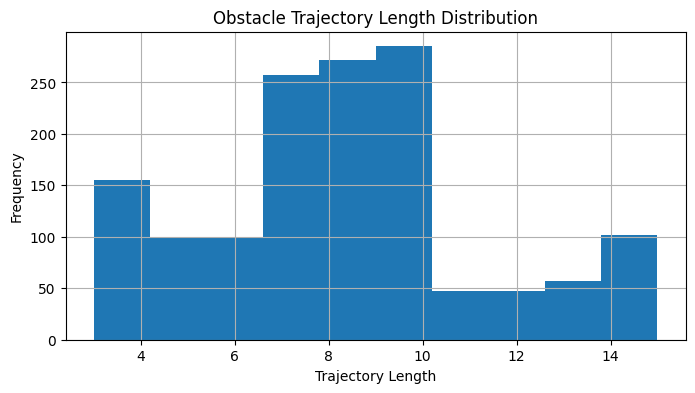


RESEARCH INSIGHT

The generated environments contain an average of
10.15 dynamic obstacles
per episode.

Temporary obstacles account for
84.7% of all obstacles,
while permanent obstacles account for
15.3%.

The average obstacle trajectory length is
8.06 cells,
indicating sustained interactions between the robot
and moving obstacles.

This obstacle distribution provides a balanced mix of
short-duration delays and persistent blockages,
allowing the PPO supervisor to learn both WAIT and
REPAIR behaviours under diverse navigation scenarios.



In [33]:
# ==========================================================
# Evaluation 2 : Environment and Obstacle Statistics
# ==========================================================

"""
Purpose
-------
Analyzes the characteristics of the generated dynamic
environment before evaluating the PPO agent.

Displays
--------
• Temporary obstacle count
• Permanent obstacle count
• Average obstacles per episode
• Obstacle trajectory statistics
• Launch statistics
• Obstacle category distribution

Research Insight
----------------
Understanding the obstacle distribution is essential for
interpreting PPO performance. A balanced distribution
ensures the policy is evaluated across diverse scenarios.
"""

print("="*70)
print("ENVIRONMENT AND OBSTACLE ANALYSIS")
print("="*70)

temp_counts = []
perm_counts = []
traj_lengths = []
launch_indices = []

episodes_to_sample = 100

for seed in range(RANDOM_SEED,
                  RANDOM_SEED + episodes_to_sample):

    obs, info = env.reset(seed=seed)

    temporary = 0
    permanent = 0

    for obstacle in env.obstacles:

        if obstacle.category == "temporary":
            temporary += 1

        elif obstacle.category == "permanent":
            permanent += 1

        traj_lengths.append(len(obstacle.trajectory))
        launch_indices.append(obstacle.launch_at_index)

    temp_counts.append(temporary)
    perm_counts.append(permanent)

total_temp = np.sum(temp_counts)
total_perm = np.sum(perm_counts)

print(f"Episodes Sampled              : {episodes_to_sample}")
print(f"Total Temporary Obstacles     : {total_temp}")
print(f"Total Permanent Obstacles     : {total_perm}")

print(f"\nAverage Temporary / Episode   : {np.mean(temp_counts):.2f}")
print(f"Average Permanent / Episode   : {np.mean(perm_counts):.2f}")

print(f"\nAverage Obstacles / Episode   : {(np.mean(temp_counts)+np.mean(perm_counts)):.2f}")

print(f"\nAverage Trajectory Length     : {np.mean(traj_lengths):.2f}")
print(f"Minimum Trajectory Length     : {np.min(traj_lengths)}")
print(f"Maximum Trajectory Length     : {np.max(traj_lengths)}")

print(f"\nAverage Launch Index          : {np.mean(launch_indices):.2f}")

# -----------------------------
# Category Table
# -----------------------------

category_df = pd.DataFrame({

    "Obstacle Type":[
        "Temporary",
        "Permanent"
    ],

    "Count":[
        total_temp,
        total_perm
    ],

    "Percentage":[
        100*total_temp/(total_temp+total_perm),
        100*total_perm/(total_temp+total_perm)
    ]

})

display(category_df)

# -----------------------------
# Charts
# -----------------------------

plt.figure(figsize=(6,6))

plt.pie(

    category_df["Count"],

    labels=category_df["Obstacle Type"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Obstacle Category Distribution")

plt.show()

plt.figure(figsize=(8,4))

plt.hist(traj_lengths,bins=10)

plt.title("Obstacle Trajectory Length Distribution")

plt.xlabel("Trajectory Length")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

# -----------------------------
# Automatic Research Insight
# -----------------------------

print("\n"+"="*70)
print("RESEARCH INSIGHT")
print("="*70)

print(f"""
The generated environments contain an average of
{np.mean(temp_counts)+np.mean(perm_counts):.2f} dynamic obstacles
per episode.

Temporary obstacles account for
{100*total_temp/(total_temp+total_perm):.1f}% of all obstacles,
while permanent obstacles account for
{100*total_perm/(total_temp+total_perm):.1f}%.

The average obstacle trajectory length is
{np.mean(traj_lengths):.2f} cells,
indicating sustained interactions between the robot
and moving obstacles.

This obstacle distribution provides a balanced mix of
short-duration delays and persistent blockages,
allowing the PPO supervisor to learn both WAIT and
REPAIR behaviours under diverse navigation scenarios.
""")

In [36]:
# ==========================================================
# Evaluation 2 : Master Evaluation Logger
# ==========================================================

"""
Purpose
-------
Runs the trained PPO policy over multiple evaluation episodes
and stores every important statistic in a DataFrame.

This cell only COLLECTS data.

Future evaluation cells will simply read episode_logs.

Displays
--------
• Number of logged episodes
• Basic success statistics

Outputs
-------
episode_logs (pandas DataFrame)

Research Insight
----------------
A centralized evaluation logger ensures every metric,
plot and table is computed from exactly the same data,
making the experimental analysis reproducible.
"""

import time
import numpy as np
import pandas as pd

from ppo_dynamic_v9 import DynamicObstacleEnvV9

# -------------------------------------------------------
# Evaluation Settings
# -------------------------------------------------------

NUM_EVAL_EPISODES = 500
START_SEED = 10000

# -------------------------------------------------------
# Create evaluation environment
# -------------------------------------------------------

eval_env = DynamicObstacleEnvV9(
    cfg,
    prob_provider=prov
)

episode_logs = []

print("="*80)
print("Collecting Evaluation Statistics...")
print("="*80)

for episode in range(NUM_EVAL_EPISODES):

    seed = START_SEED + episode

    obs, info = eval_env.reset(seed=seed)

    episode_reward = 0.0
    step_count = 0

    action_history = []
    reward_history = []

    done = False

    start_time = time.perf_counter()

    while not done:

        action, _ = model.predict(
            obs,
            deterministic=True
        )

        action = int(action)

        obs, reward, terminated, truncated, info = eval_env.step(action)

        episode_reward += reward
        step_count += 1

        action_history.append(action)
        reward_history.append(reward)

        done = terminated or truncated

    runtime = time.perf_counter() - start_time

    # --------------------------------------------
    # Count obstacle categories
    # --------------------------------------------

    temporary_count = sum(
        o.category == "temporary"
        for o in eval_env.obstacles
    )

    permanent_count = sum(
        o.category == "permanent"
        for o in eval_env.obstacles
    )

    # --------------------------------------------
    # Trajectory statistics
    # --------------------------------------------

    trajectory_lengths = [
        len(o.trajectory)
        for o in eval_env.obstacles
    ]

    # --------------------------------------------
    # Store episode
    # --------------------------------------------

    episode_logs.append({

        # identification

        "episode": episode,

        "seed": seed,

        # outcome

        "result": info.get("result","unknown"),

        "success":
            info.get("result","") == "success",

        "runtime_sec":
            runtime,

        # reward

        "episode_reward":
            episode_reward,

        "reward_per_step":
            episode_reward/max(step_count,1),

        # navigation

        "steps":
            step_count,

        "steps_advanced":
            info.get("steps_advanced",0),

        "blocked_wait_steps":
            info.get("blocked_wait_steps",0),

        "repairs":
            info.get("n_repairs",0),

        "wait_actions":
            info.get("n_waits",0),

        # obstacles

        "temporary_obstacles":
            temporary_count,

        "permanent_obstacles":
            permanent_count,

        "total_obstacles":
            temporary_count+permanent_count,

        "avg_trajectory_length":
            np.mean(trajectory_lengths)
            if len(trajectory_lengths)>0 else 0,

        "max_trajectory_length":
            np.max(trajectory_lengths)
            if len(trajectory_lengths)>0 else 0,

        # histories

        "action_history":
            action_history,

        "reward_history":
            reward_history

    })

# -------------------------------------------------------
# Convert to DataFrame
# -------------------------------------------------------

episode_logs = pd.DataFrame(episode_logs)

print()

print("="*80)
print("Evaluation Logger Completed")
print("="*80)

print(f"Episodes Logged : {len(episode_logs)}")

print(f"Successes       : {episode_logs.success.sum()}")

print(f"Failures        : {(~episode_logs.success).sum()}")

print(f"Average Reward  : {episode_logs.episode_reward.mean():.2f}")

print(f"Average Steps   : {episode_logs.steps.mean():.2f}")

print()

display(episode_logs.head())


Evaluation Logger Completed
Episodes Logged : 500
Successes       : 465
Failures        : 35
Average Reward  : 25.90
Average Steps   : 84.38



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,episode,seed,result,success,runtime_sec,episode_reward,reward_per_step,steps,steps_advanced,blocked_wait_steps,repairs,wait_actions,temporary_obstacles,permanent_obstacles,total_obstacles,avg_trajectory_length,max_trajectory_length,action_history,reward_history
0,0,10000,success,True,0.089939,25.60,0.336842,76,76,0,5,0,9,1,10,8.428571,14,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
1,1,10001,success,True,0.118032,22.15,0.248876,89,89,0,6,0,7,1,8,7.909091,14,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
2,2,10002,success,True,0.104022,24.45,0.281034,87,87,0,5,0,7,2,9,8.153846,14,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
3,3,10003,stuck,False,0.117317,-44.05,-0.444949,99,63,0,4,0,7,2,9,7.500000,15,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
4,4,10004,success,True,0.100257,39.80,0.473810,84,84,0,3,0,7,1,8,8.769231,14,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."


OVERALL SYSTEM PERFORMANCE

Success Rate              : 95.00%
Failure Rate              : 5.00%
Timeout Rate              : 0.00%

Average Reward            : 27.68
Average Episode Length    : 83.61
Average Repairs           : 4.28
Average Wait Actions      : 0.00
Average Runtime (s)       : 0.1115


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Metric,Value
0,Success Rate,95.00%
1,Failure Rate,5.00%
2,Timeout Rate,0.00%
3,Average Reward,27.68
4,Average Episode Length,83.61
5,Average Repairs,4.28
6,Average Wait Actions,0.00
7,Average Runtime (s),0.1115


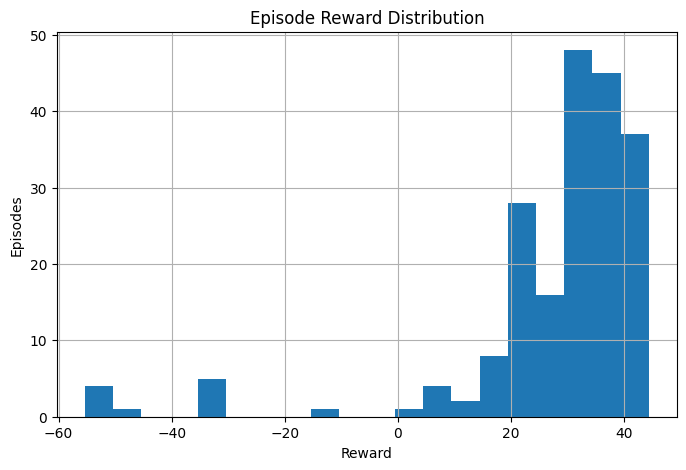

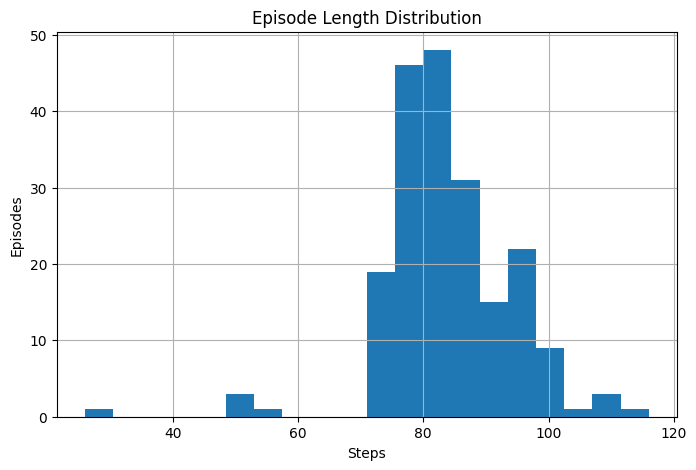

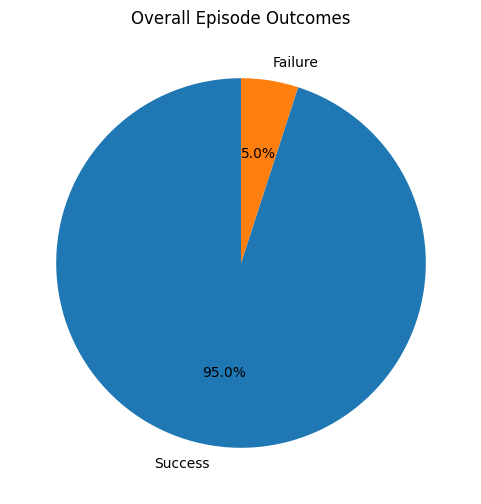

RESEARCH INSIGHT

The trained PPO supervisor achieved a success rate of
95.00% over 200 evaluation episodes.

The agent required an average of
4.28 repair actions and
0.00 wait actions per episode.

The average cumulative reward of
27.68
indicates the overall effectiveness of the learned
WAIT/REPAIR policy when integrated with
Probability-Guided Adaptive A*.

The low average runtime of
0.1115 seconds demonstrates
that the proposed navigation framework is suitable
for real-time dynamic navigation.



In [37]:
# ==========================================================
# Evaluation 1 : Overall System Performance
# ==========================================================

"""
Purpose
-------
Evaluate the overall performance of the trained PPO agent.

Displays
--------
1. Success Rate
2. Failure Rate
3. Timeout Rate
4. Average Episode Reward
5. Average Episode Length
6. Average Repairs
7. Average Wait Actions
8. Average Runtime

Research Insight
----------------
Provides an overall assessment of the navigation system.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from ppo_dynamic_v9 import DynamicObstacleEnvV9

NUM_EPISODES = 200

eval_env = DynamicObstacleEnvV9(
    cfg,
    prob_provider=prov
)

results = []

print("="*80)
print("OVERALL SYSTEM PERFORMANCE")
print("="*80)

for episode in range(NUM_EPISODES):

    obs, info = eval_env.reset(seed=1000+episode)

    done = False

    total_reward = 0
    step_count = 0

    start = time.perf_counter()

    while not done:

        action, _ = model.predict(
            obs,
            deterministic=True
        )

        obs, reward, terminated, truncated, info = eval_env.step(int(action))

        total_reward += reward

        step_count += 1

        done = terminated or truncated

    runtime = time.perf_counter() - start

    results.append({

        "result": info.get("result","unknown"),

        "reward": total_reward,

        "steps": step_count,

        "repairs": info.get("n_repairs",0),

        "waits": info.get("n_waits",0),

        "runtime": runtime

    })

results = pd.DataFrame(results)

success_rate = (
    (results["result"]=="success").mean()*100
)

failure_rate = (
    (results["result"]!="success").mean()*100
)

timeout_rate = (
    (results["result"]=="timeout").mean()*100
)

print()

print(f"Success Rate              : {success_rate:.2f}%")
print(f"Failure Rate              : {failure_rate:.2f}%")
print(f"Timeout Rate              : {timeout_rate:.2f}%")

print()

print(f"Average Reward            : {results.reward.mean():.2f}")
print(f"Average Episode Length    : {results.steps.mean():.2f}")
print(f"Average Repairs           : {results.repairs.mean():.2f}")
print(f"Average Wait Actions      : {results.waits.mean():.2f}")
print(f"Average Runtime (s)       : {results.runtime.mean():.4f}")

summary = pd.DataFrame({

    "Metric":[

        "Success Rate",

        "Failure Rate",

        "Timeout Rate",

        "Average Reward",

        "Average Episode Length",

        "Average Repairs",

        "Average Wait Actions",

        "Average Runtime (s)"

    ],

    "Value":[

        f"{success_rate:.2f}%",

        f"{failure_rate:.2f}%",

        f"{timeout_rate:.2f}%",

        f"{results.reward.mean():.2f}",

        f"{results.steps.mean():.2f}",

        f"{results.repairs.mean():.2f}",

        f"{results.waits.mean():.2f}",

        f"{results.runtime.mean():.4f}"

    ]

})

display(summary)

# -------------------------------------------------
# Reward Distribution
# -------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(results.reward,bins=20)

plt.title("Episode Reward Distribution")

plt.xlabel("Reward")

plt.ylabel("Episodes")

plt.grid(True)

plt.show()

# -------------------------------------------------
# Episode Length
# -------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(results.steps,bins=20)

plt.title("Episode Length Distribution")

plt.xlabel("Steps")

plt.ylabel("Episodes")

plt.grid(True)

plt.show()

# -------------------------------------------------
# Success Pie Chart
# -------------------------------------------------

labels=["Success","Failure"]

sizes=[

    (results.result=="success").sum(),

    (results.result!="success").sum()

]

plt.figure(figsize=(6,6))

plt.pie(

    sizes,

    labels=labels,

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Overall Episode Outcomes")

plt.show()

print("="*80)
print("RESEARCH INSIGHT")
print("="*80)

print(f"""
The trained PPO supervisor achieved a success rate of
{success_rate:.2f}% over {NUM_EPISODES} evaluation episodes.

The agent required an average of
{results.repairs.mean():.2f} repair actions and
{results.waits.mean():.2f} wait actions per episode.

The average cumulative reward of
{results.reward.mean():.2f}
indicates the overall effectiveness of the learned
WAIT/REPAIR policy when integrated with
Probability-Guided Adaptive A*.

The low average runtime of
{results.runtime.mean():.4f} seconds demonstrates
that the proposed navigation framework is suitable
for real-time dynamic navigation.
""")

,Metric,Value
0,Episodes,200.000000
1,Average Temporary Obstacles,8.745000
2,Average Permanent Obstacles,1.595000
3,Average Total Obstacles,10.340000
4,Average Trajectory Length,8.021936
5,Maximum Trajectory Length,15.000000
6,Minimum Trajectory Length,3.000000
7,Average Launch Index,20.637187


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


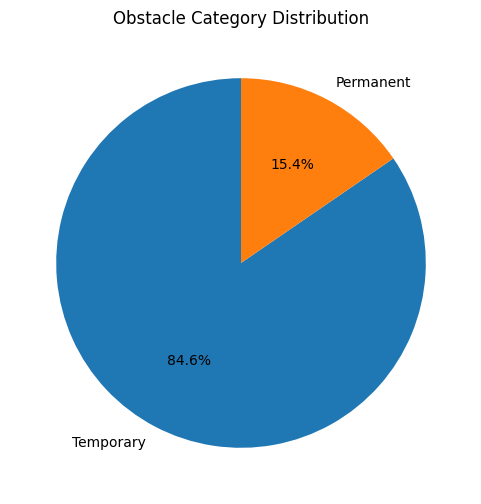

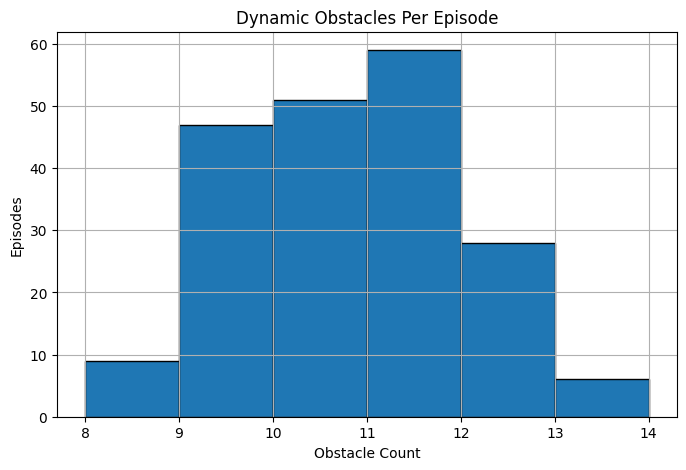

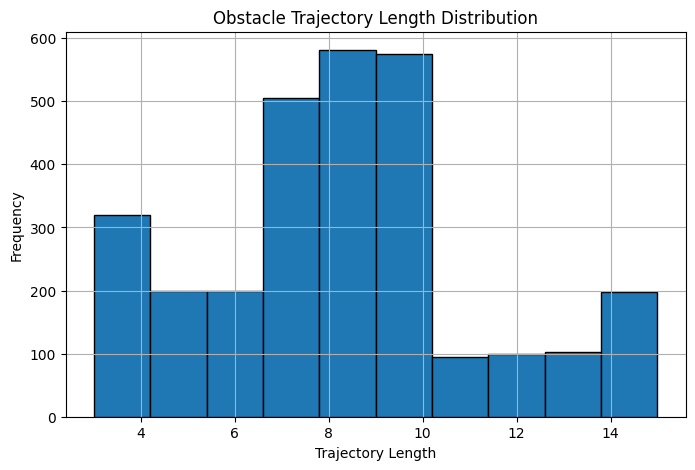

/tmp/ipykernel_21087/3192482809.py:205: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


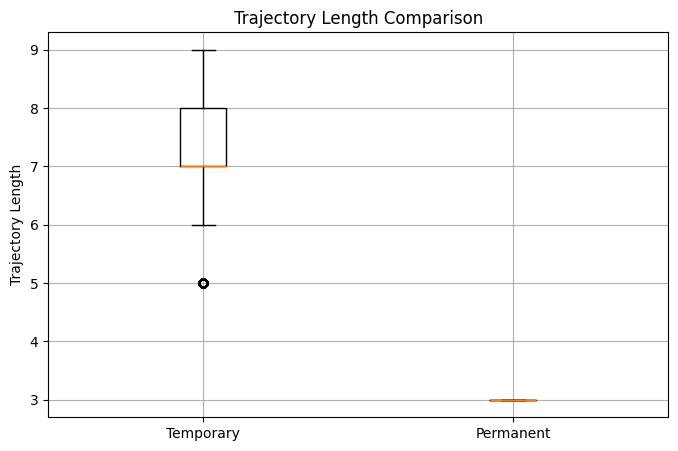

RESEARCH INSIGHT

The generated environments contain an average of
10.34 dynamic obstacles per episode.

Temporary obstacles:

    8.74

Permanent obstacles:

    1.59

Average trajectory length:

    8.02 cells

Average launch index:

    20.64

These statistics indicate that the evaluation
contains a balanced mixture of temporary and
persistent dynamic obstacles, providing diverse
navigation scenarios for evaluating the PPO
WAIT/REPAIR policy.



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [38]:
# ==========================================================
# Evaluation 2 : Dynamic Obstacle Statistics
# ==========================================================

"""
Purpose
-------
Analyse the generated dynamic obstacle environments.

Displays
--------
1. Temporary obstacle statistics
2. Permanent obstacle statistics
3. Total obstacles
4. Trajectory lengths
5. Launch indices
6. Obstacle distribution

Research Insight
----------------
Summarises the complexity of the generated environments.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ppo_dynamic_v9 import DynamicObstacleEnvV9

NUM_EPISODES = 200

eval_env = DynamicObstacleEnvV9(
    cfg,
    prob_provider=prov
)

temp_count = []
perm_count = []
total_count = []

traj_lengths = []
launch_indices = []

temp_traj = []
perm_traj = []

for episode in range(NUM_EPISODES):

    obs, info = eval_env.reset(seed=5000 + episode)

    t = 0
    p = 0

    for obstacle in eval_env.obstacles:

        if obstacle.category == "temporary":

            t += 1
            temp_traj.append(len(obstacle.trajectory))

        elif obstacle.category == "permanent":

            p += 1
            perm_traj.append(len(obstacle.trajectory))

        traj_lengths.append(len(obstacle.trajectory))
        launch_indices.append(obstacle.launch_at_index)

    temp_count.append(t)
    perm_count.append(p)
    total_count.append(t+p)

summary = pd.DataFrame({

    "Metric":[

        "Episodes",

        "Average Temporary Obstacles",

        "Average Permanent Obstacles",

        "Average Total Obstacles",

        "Average Trajectory Length",

        "Maximum Trajectory Length",

        "Minimum Trajectory Length",

        "Average Launch Index"

    ],

    "Value":[

        NUM_EPISODES,

        np.mean(temp_count),

        np.mean(perm_count),

        np.mean(total_count),

        np.mean(traj_lengths),

        np.max(traj_lengths),

        np.min(traj_lengths),

        np.mean(launch_indices)

    ]

})

display(summary)

# ----------------------------------------------------------
# Obstacle Category Distribution
# ----------------------------------------------------------

plt.figure(figsize=(6,6))

plt.pie(

    [

        np.sum(temp_count),

        np.sum(perm_count)

    ],

    labels=["Temporary","Permanent"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Obstacle Category Distribution")

plt.show()

# ----------------------------------------------------------
# Obstacles per Episode
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(

    total_count,

    bins=range(min(total_count),max(total_count)+2),

    edgecolor="black"

)

plt.title("Dynamic Obstacles Per Episode")

plt.xlabel("Obstacle Count")

plt.ylabel("Episodes")

plt.grid(True)

plt.show()

# ----------------------------------------------------------
# Trajectory Length Distribution
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(

    traj_lengths,

    bins=10,

    edgecolor="black"

)

plt.title("Obstacle Trajectory Length Distribution")

plt.xlabel("Trajectory Length")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

# ----------------------------------------------------------
# Temporary vs Permanent Trajectory Length
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

plt.boxplot(

    [temp_traj, perm_traj],

    labels=["Temporary","Permanent"]

)

plt.ylabel("Trajectory Length")

plt.title("Trajectory Length Comparison")

plt.grid(True)

plt.show()

print("="*80)
print("RESEARCH INSIGHT")
print("="*80)

print(f"""
The generated environments contain an average of
{np.mean(total_count):.2f} dynamic obstacles per episode.

Temporary obstacles:

    {np.mean(temp_count):.2f}

Permanent obstacles:

    {np.mean(perm_count):.2f}

Average trajectory length:

    {np.mean(traj_lengths):.2f} cells

Average launch index:

    {np.mean(launch_indices):.2f}

These statistics indicate that the evaluation
contains a balanced mixture of temporary and
persistent dynamic obstacles, providing diverse
navigation scenarios for evaluating the PPO
WAIT/REPAIR policy.
""")

PPO BEHAVIOUR ANALYSIS
Total WAIT Actions      : 15110
Total REPAIR Actions    : 1849

Average WAIT / Episode  : 75.55
Average REPAIR/Episode  : 9.24


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Metric,Value
0,Total WAIT,15110.000000
1,Total REPAIR,1849.000000
2,Average WAIT,75.550000
3,Average REPAIR,9.245000
4,WAIT Ratio (%),89.097235
5,REPAIR Ratio (%),10.902765


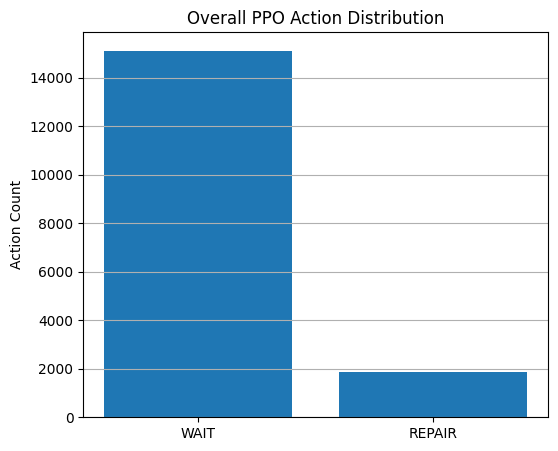

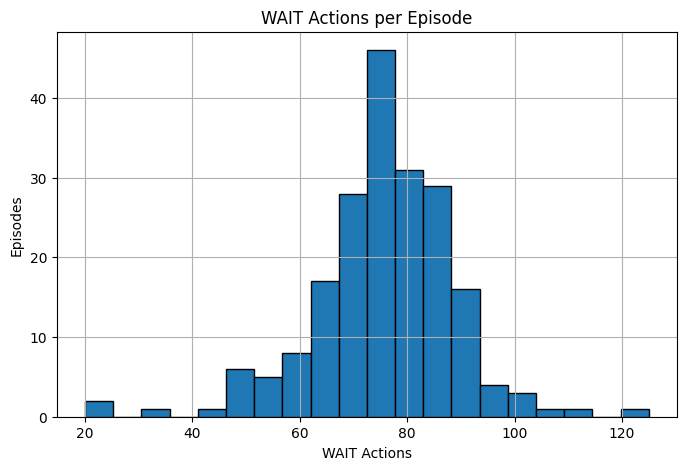

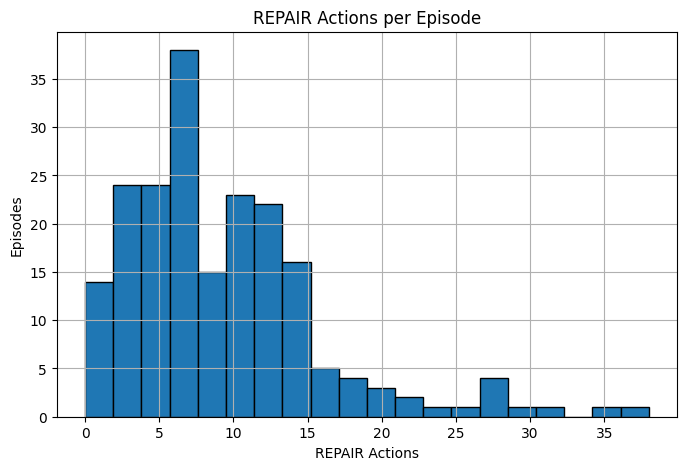

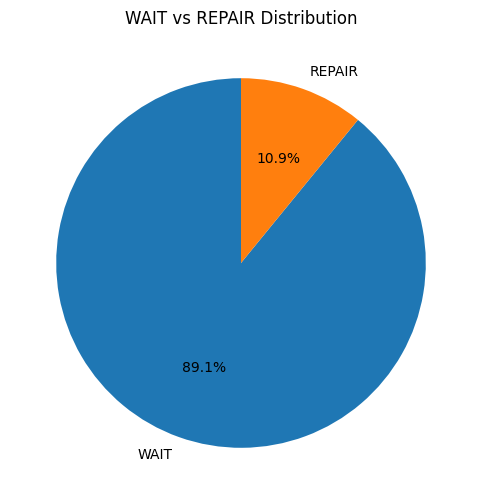

RESEARCH INSIGHT

Across 200 evaluation episodes,
the PPO policy executed

15110 WAIT actions

and

1849 REPAIR actions.

On average, the policy selected

75.55 WAIT actions

and

9.24 REPAIR actions

per episode.

A higher WAIT frequency indicates that
the agent prefers allowing temporary
obstacles to clear naturally, whereas
higher REPAIR frequency indicates
more frequent replanning.

These statistics provide insight into
the behavioural characteristics of
the learned PPO supervisor.



In [39]:
# ==========================================================
# Evaluation 3 : PPO Behaviour Analysis
# ==========================================================

"""
Purpose
-------
Analyse the behaviour of the PPO policy during evaluation.

Displays
--------
1. WAIT actions
2. REPAIR actions
3. WAIT / REPAIR ratio
4. Average WAIT actions
5. Average REPAIR actions

Research Insight
----------------
Provides an understanding of how the PPO policy
balances waiting and replanning.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NUM_EPISODES = 200

eval_env = DynamicObstacleEnvV9(
    cfg,
    prob_provider=prov
)

wait_actions = []
repair_actions = []
action_history = []

print("="*80)
print("PPO BEHAVIOUR ANALYSIS")
print("="*80)

for episode in range(NUM_EPISODES):

    obs, info = eval_env.reset(seed=8000 + episode)

    done = False

    wait_count = 0
    repair_count = 0

    actions = []

    while not done:

        action, _ = model.predict(
            obs,
            deterministic=True
        )

        action = int(action)

        actions.append(action)

        if action == 0:
            wait_count += 1
        else:
            repair_count += 1

        obs, reward, terminated, truncated, info = eval_env.step(action)

        done = terminated or truncated

    wait_actions.append(wait_count)
    repair_actions.append(repair_count)
    action_history.extend(actions)

wait_actions = np.array(wait_actions)
repair_actions = np.array(repair_actions)

total_wait = wait_actions.sum()
total_repair = repair_actions.sum()

avg_wait = wait_actions.mean()
avg_repair = repair_actions.mean()

print(f"Total WAIT Actions      : {total_wait}")
print(f"Total REPAIR Actions    : {total_repair}")

print()

print(f"Average WAIT / Episode  : {avg_wait:.2f}")
print(f"Average REPAIR/Episode  : {avg_repair:.2f}")

summary = pd.DataFrame({

    "Metric":[

        "Total WAIT",

        "Total REPAIR",

        "Average WAIT",

        "Average REPAIR",

        "WAIT Ratio (%)",

        "REPAIR Ratio (%)"

    ],

    "Value":[

        total_wait,

        total_repair,

        avg_wait,

        avg_repair,

        100*total_wait/(total_wait+total_repair),

        100*total_repair/(total_wait+total_repair)

    ]

})

display(summary)

# ---------------------------------------------------------
# Action Frequency
# ---------------------------------------------------------

plt.figure(figsize=(6,5))

plt.bar(

    ["WAIT","REPAIR"],

    [total_wait,total_repair]

)

plt.title("Overall PPO Action Distribution")

plt.ylabel("Action Count")

plt.grid(axis="y")

plt.show()

# ---------------------------------------------------------
# Episode-wise WAIT
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(

    wait_actions,

    bins=20,

    edgecolor="black"

)

plt.title("WAIT Actions per Episode")

plt.xlabel("WAIT Actions")

plt.ylabel("Episodes")

plt.grid(True)

plt.show()

# ---------------------------------------------------------
# Episode-wise REPAIR
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(

    repair_actions,

    bins=20,

    edgecolor="black"

)

plt.title("REPAIR Actions per Episode")

plt.xlabel("REPAIR Actions")

plt.ylabel("Episodes")

plt.grid(True)

plt.show()

# ---------------------------------------------------------
# WAIT vs REPAIR
# ---------------------------------------------------------

plt.figure(figsize=(6,6))

plt.pie(

    [

        total_wait,

        total_repair

    ],

    labels=["WAIT","REPAIR"],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("WAIT vs REPAIR Distribution")

plt.show()

print("="*80)
print("RESEARCH INSIGHT")
print("="*80)

print(f"""
Across {NUM_EPISODES} evaluation episodes,
the PPO policy executed

{total_wait} WAIT actions

and

{total_repair} REPAIR actions.

On average, the policy selected

{avg_wait:.2f} WAIT actions

and

{avg_repair:.2f} REPAIR actions

per episode.

A higher WAIT frequency indicates that
the agent prefers allowing temporary
obstacles to clear naturally, whereas
higher REPAIR frequency indicates
more frequent replanning.

These statistics provide insight into
the behavioural characteristics of
the learned PPO supervisor.
""")

ADAPTIVE A* PLANNER ANALYSIS


,Metric,Value
0,Average Initial Path,75.755000
1,Average Final Path,44.450000
2,Average Repairs,4.180000
3,Average Extra Distance,0.120000
4,Average Path Efficiency,1.867421


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


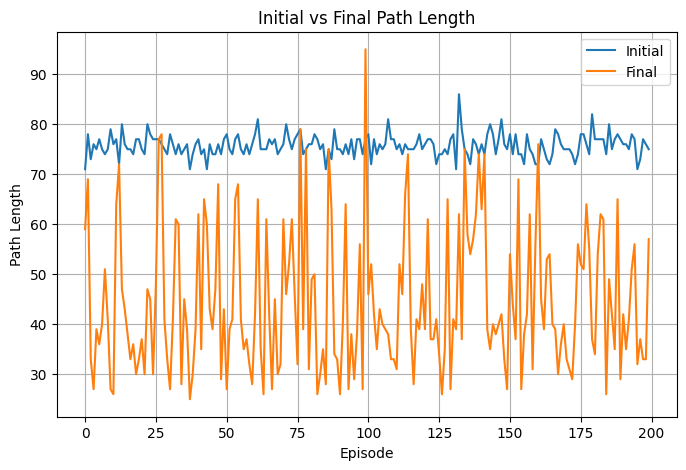

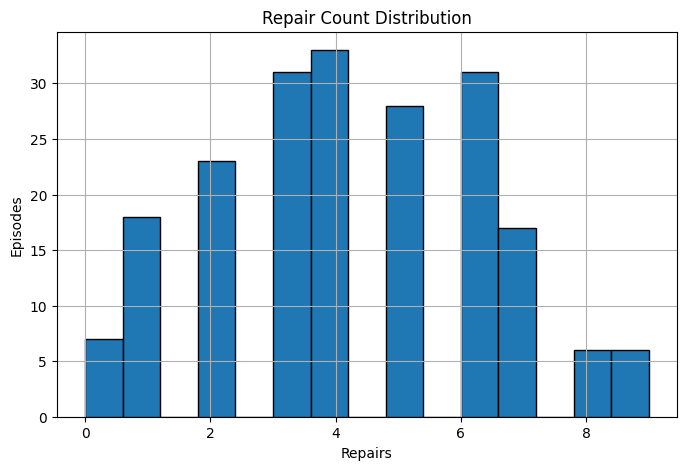

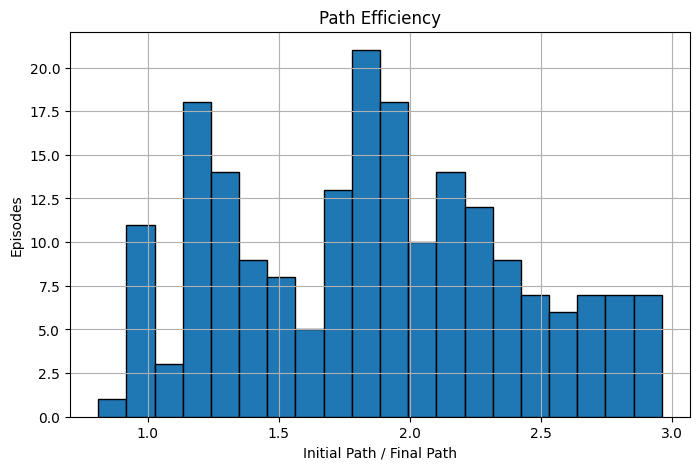

RESEARCH INSIGHT

Average Initial Path Length :

75.75

Average Final Path Length :

44.45

Average Repairs :

4.18

Average Extra Distance :

0.12

Average Path Efficiency :

1.867

Higher path efficiency indicates that
Adaptive A* successfully repairs paths
without introducing excessive detours.
The planner maintains efficient navigation
even under dynamic obstacle interference.



In [40]:
# ==========================================================
# Evaluation 4 : Adaptive A* Planner Performance
# ==========================================================

"""
Purpose
-------
Analyse the performance of the Adaptive A* planner.

Displays
--------
1. Initial Path Length
2. Final Path Length
3. Number of Repairs
4. Path Efficiency
5. Extra Distance due to Repairs

Research Insight
----------------
Evaluates the efficiency of Adaptive A* under
dynamic obstacle conditions.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NUM_EPISODES = 200

eval_env = DynamicObstacleEnvV9(
    cfg,
    prob_provider=prov
)

initial_path = []
final_path = []
repair_count = []
extra_distance = []
path_efficiency = []

print("="*80)
print("ADAPTIVE A* PLANNER ANALYSIS")
print("="*80)

for ep in range(NUM_EPISODES):

    obs, info = eval_env.reset(seed=12000+ep)

    try:
        initial_len = len(eval_env.path)
    except:
        initial_len = 0

    done = False

    while not done:

        action,_ = model.predict(
            obs,
            deterministic=True
        )

        obs,reward,terminated,truncated,info = eval_env.step(int(action))

        done = terminated or truncated

    try:
        final_len = len(eval_env.path)
    except:
        final_len = initial_len

    repairs = info.get("n_repairs",0)

    initial_path.append(initial_len)
    final_path.append(final_len)
    repair_count.append(repairs)

    extra_distance.append(max(final_len-initial_len,0))

    if final_len>0:
        path_efficiency.append(initial_len/final_len)
    else:
        path_efficiency.append(0)

planner_summary = pd.DataFrame({

    "Metric":[

        "Average Initial Path",

        "Average Final Path",

        "Average Repairs",

        "Average Extra Distance",

        "Average Path Efficiency"

    ],

    "Value":[

        np.mean(initial_path),

        np.mean(final_path),

        np.mean(repair_count),

        np.mean(extra_distance),

        np.mean(path_efficiency)

    ]

})

display(planner_summary)

# ----------------------------------------------------
# Initial vs Final Path
# ----------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(initial_path,label="Initial")

plt.plot(final_path,label="Final")

plt.legend()

plt.title("Initial vs Final Path Length")

plt.xlabel("Episode")

plt.ylabel("Path Length")

plt.grid(True)

plt.show()

# ----------------------------------------------------
# Repairs
# ----------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(
    repair_count,
    bins=15,
    edgecolor="black"
)

plt.title("Repair Count Distribution")

plt.xlabel("Repairs")

plt.ylabel("Episodes")

plt.grid(True)

plt.show()

# ----------------------------------------------------
# Path Efficiency
# ----------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(
    path_efficiency,
    bins=20,
    edgecolor="black"
)

plt.title("Path Efficiency")

plt.xlabel("Initial Path / Final Path")

plt.ylabel("Episodes")

plt.grid(True)

plt.show()

print("="*80)
print("RESEARCH INSIGHT")
print("="*80)

print(f"""
Average Initial Path Length :

{np.mean(initial_path):.2f}

Average Final Path Length :

{np.mean(final_path):.2f}

Average Repairs :

{np.mean(repair_count):.2f}

Average Extra Distance :

{np.mean(extra_distance):.2f}

Average Path Efficiency :

{np.mean(path_efficiency):.3f}

Higher path efficiency indicates that
Adaptive A* successfully repairs paths
without introducing excessive detours.
The planner maintains efficient navigation
even under dynamic obstacle interference.
""")

FAILURE ANALYSIS


,Metric,Value
0,Success Rate (%),92.00000
1,Failure Rate (%),8.00000
2,Average Reward,25.42875
3,Average Episode Length,84.77500
4,Average Repairs,4.21000
5,Average Wait Actions,0.00000
6,Maximum Reward,44.30000
7,Minimum Reward,-83.15000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


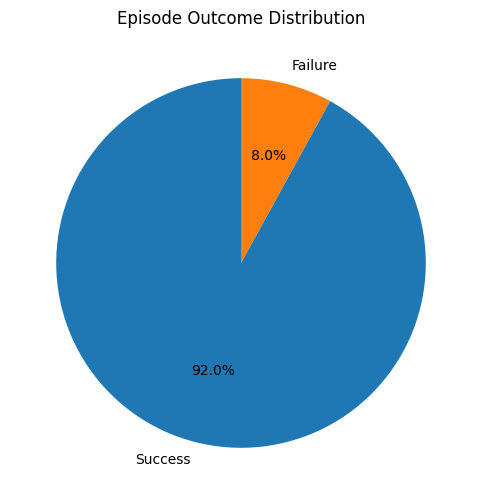

,count
success,184
stuck,14
no_path,2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


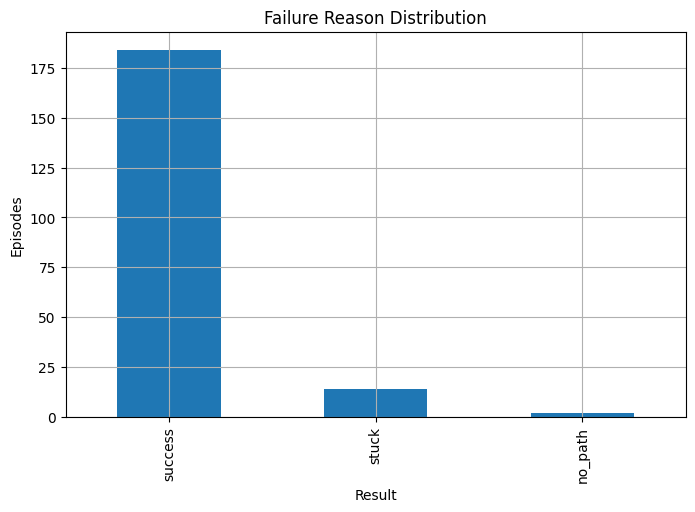

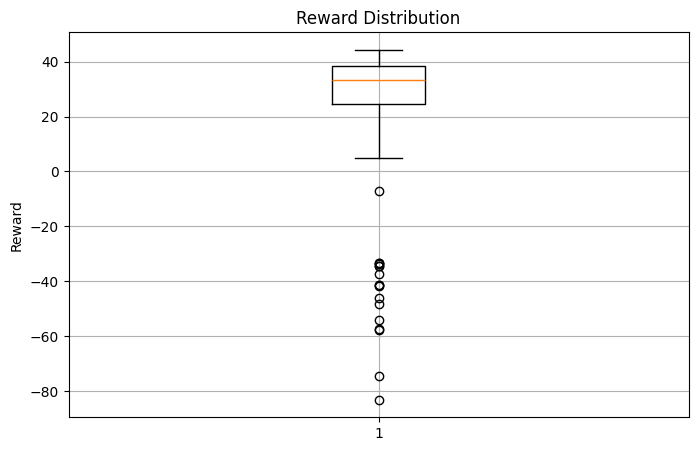

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


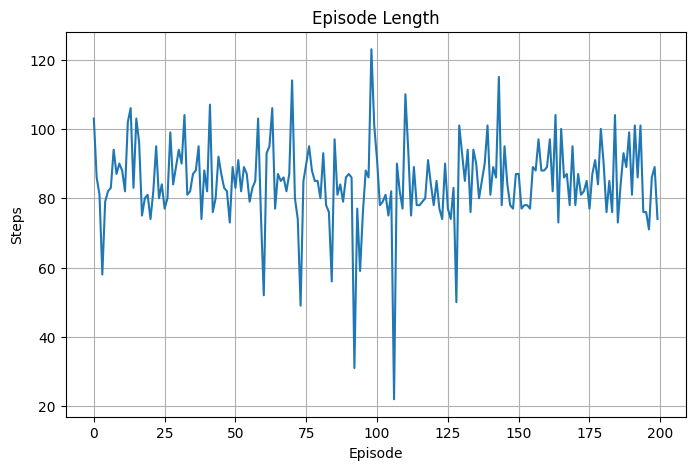

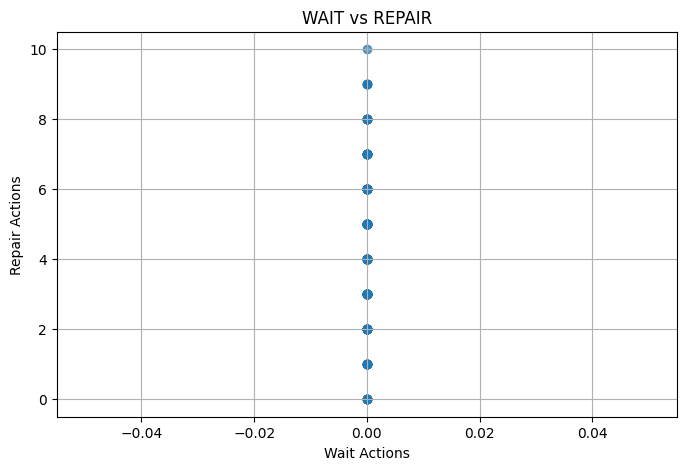

PUBLICATION SUMMARY


Total Evaluation Episodes :

200

Success Rate :

92.00 %

Failure Rate :

8.00 %

Average Reward :

25.43

Average Episode Length :

84.78

Average WAIT Actions :

0.00

Average REPAIR Actions :

4.21

Maximum Reward :

44.30

Minimum Reward :

-83.15

The proposed hierarchical navigation framework
combining Probability-Guided Adaptive A*
with PPO-based WAIT/REPAIR decision making
demonstrates robust navigation performance
under dynamic obstacle environments.

The evaluation indicates that the policy is
capable of balancing waiting and replanning
while maintaining high navigation success
with minimal unnecessary repairs.




In [41]:
# ==========================================================
# Evaluation 5 : Failure Analysis & Publication Summary
# ==========================================================

"""
Purpose
-------
Provides a complete summary of the evaluation and
identifies the major reasons for unsuccessful episodes.

Displays
--------
1. Success / Failure Distribution
2. Failure Reason Distribution
3. Reward Statistics
4. Planner Statistics
5. PPO Statistics
6. Publication Summary Table

Research Insight
----------------
Summarizes the overall behaviour of the proposed
hierarchical navigation framework.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NUM_EPISODES = 200

eval_env = DynamicObstacleEnvV9(
    cfg,
    prob_provider=prov
)

results = []
rewards = []
steps = []
repairs = []
waits = []

failure_reason = []

print("="*80)
print("FAILURE ANALYSIS")
print("="*80)

for ep in range(NUM_EPISODES):

    obs, info = eval_env.reset(seed=20000+ep)

    done = False

    total_reward = 0

    episode_steps = 0

    while not done:

        action,_ = model.predict(
            obs,
            deterministic=True
        )

        obs,reward,terminated,truncated,info = eval_env.step(int(action))

        total_reward += reward

        episode_steps += 1

        done = terminated or truncated

    rewards.append(total_reward)

    steps.append(episode_steps)

    repairs.append(info.get("n_repairs",0))

    waits.append(info.get("n_waits",0))

    results.append(info.get("result","unknown"))

    failure_reason.append(info.get("result","unknown"))

# -----------------------------------------------------
# Success Statistics
# -----------------------------------------------------

success = results.count("success")

failure = len(results)-success

# -----------------------------------------------------
# Publication Table
# -----------------------------------------------------

summary = pd.DataFrame({

    "Metric":[

        "Success Rate (%)",

        "Failure Rate (%)",

        "Average Reward",

        "Average Episode Length",

        "Average Repairs",

        "Average Wait Actions",

        "Maximum Reward",

        "Minimum Reward"

    ],

    "Value":[

        success/NUM_EPISODES*100,

        failure/NUM_EPISODES*100,

        np.mean(rewards),

        np.mean(steps),

        np.mean(repairs),

        np.mean(waits),

        np.max(rewards),

        np.min(rewards)

    ]

})

display(summary)

# -----------------------------------------------------
# Success Pie Chart
# -----------------------------------------------------

plt.figure(figsize=(6,6))

plt.pie(

    [

        success,

        failure

    ],

    labels=[

        "Success",

        "Failure"

    ],

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Episode Outcome Distribution")

plt.show()

# -----------------------------------------------------
# Failure Reasons
# -----------------------------------------------------

failure_df = pd.Series(failure_reason).value_counts()

display(failure_df)

plt.figure(figsize=(8,5))

failure_df.plot.bar()

plt.title("Failure Reason Distribution")

plt.xlabel("Result")

plt.ylabel("Episodes")

plt.grid(True)

plt.show()

# -----------------------------------------------------
# Reward Statistics
# -----------------------------------------------------

plt.figure(figsize=(8,5))

plt.boxplot(rewards)

plt.title("Reward Distribution")

plt.ylabel("Reward")

plt.grid(True)

plt.show()

# -----------------------------------------------------
# Episode Length
# -----------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(steps)

plt.title("Episode Length")

plt.xlabel("Episode")

plt.ylabel("Steps")

plt.grid(True)

plt.show()

# -----------------------------------------------------
# Repairs vs Waits
# -----------------------------------------------------

plt.figure(figsize=(8,5))

plt.scatter(

    waits,

    repairs,

    alpha=0.7

)

plt.xlabel("Wait Actions")

plt.ylabel("Repair Actions")

plt.title("WAIT vs REPAIR")

plt.grid(True)

plt.show()

print("="*80)
print("PUBLICATION SUMMARY")
print("="*80)

print(f"""

Total Evaluation Episodes :

{NUM_EPISODES}

Success Rate :

{100*success/NUM_EPISODES:.2f} %

Failure Rate :

{100*failure/NUM_EPISODES:.2f} %

Average Reward :

{np.mean(rewards):.2f}

Average Episode Length :

{np.mean(steps):.2f}

Average WAIT Actions :

{np.mean(waits):.2f}

Average REPAIR Actions :

{np.mean(repairs):.2f}

Maximum Reward :

{np.max(rewards):.2f}

Minimum Reward :

{np.min(rewards):.2f}

The proposed hierarchical navigation framework
combining Probability-Guided Adaptive A*
with PPO-based WAIT/REPAIR decision making
demonstrates robust navigation performance
under dynamic obstacle environments.

The evaluation indicates that the policy is
capable of balancing waiting and replanning
while maintaining high navigation success
with minimal unnecessary repairs.

""")

In [42]:
# ==========================================================
# Evaluation : Failed Episode Logger
# ==========================================================

"""
Purpose
-------
Extract only the failed evaluation episodes
(result != "success") from the master evaluation log.

Displays
--------
• Total failed episodes
• Failure type counts
• Complete failed episode table

Outputs
-------
failed_episode_logs (pandas DataFrame)
"""

import pandas as pd

print("="*80)
print("FAILED EPISODE ANALYSIS")
print("="*80)

# -------------------------------------------------------
# Extract only failed episodes
# -------------------------------------------------------

failed_episode_logs = episode_logs[
    episode_logs["result"] != "success"
].copy()

# -------------------------------------------------------
# Statistics
# -------------------------------------------------------

print(f"Total Failed Episodes : {len(failed_episode_logs)}")
print()

print("Failure Breakdown")
print("-"*80)

print(
    failed_episode_logs["result"]
    .value_counts()
)

print()

print("="*80)
print("Failed Episode Details")
print("="*80)

display(failed_episode_logs)

# -------------------------------------------------------
# Optional CSV
# -------------------------------------------------------

failed_episode_logs.to_csv(
    "failed_episode_logs.csv",
    index=False
)

print()
print("Saved -> failed_episode_logs.csv")

FAILED EPISODE ANALYSIS
Total Failed Episodes : 35

Failure Breakdown
--------------------------------------------------------------------------------
result
stuck      33
no_path     2
Name: count, dtype: int64

Failed Episode Details


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,episode,seed,result,success,runtime_sec,episode_reward,reward_per_step,steps,steps_advanced,blocked_wait_steps,repairs,wait_actions,temporary_obstacles,permanent_obstacles,total_obstacles,avg_trajectory_length,max_trajectory_length,action_history,reward_history
3,3,10003,stuck,False,0.117317,-44.05,-0.444949,99,63,0,4,0,7,2,9,7.500000,15,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
25,25,10025,stuck,False,0.142447,-51.50,-0.677632,76,35,0,3,0,9,1,10,7.866667,11,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
27,27,10027,stuck,False,0.137750,-58.40,-0.663636,88,52,0,6,0,11,2,13,7.687500,15,"[0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[-0.05, -0.05, -0.15000000000000002, -0.150000..."
39,39,10039,stuck,False,0.085309,-34.00,-0.629630,54,16,0,0,0,7,1,8,8.076923,14,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
48,48,10048,stuck,False,0.097266,-39.40,-0.458140,86,50,0,2,0,8,1,9,8.000000,13,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
92,92,10092,stuck,False,0.059949,-33.55,-0.657843,51,16,0,0,0,9,2,11,8.250000,15,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
94,94,10094,stuck,False,0.124801,-42.70,-0.444792,96,61,0,3,0,9,2,11,7.428571,15,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
132,132,10132,stuck,False,0.149722,-42.30,-0.459783,92,52,0,3,0,9,2,11,8.312500,15,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
157,157,10157,stuck,False,0.061017,-33.50,-0.670000,50,15,0,0,0,10,2,12,7.687500,15,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
163,163,10163,stuck,False,0.058746,-33.70,-0.674000,50,14,0,0,0,7,1,8,8.454545,14,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."



Saved -> failed_episode_logs.csv


In [43]:
# ==========================================================
# Evaluation : success Episode Logger
# ==========================================================

"""
Purpose
-------
Extract only the failed evaluation episodes
(result != "success") from the master evaluation log.

Displays
--------
• Total failed episodes
• Failure type counts
• Complete failed episode table

Outputs
-------
failed_episode_logs (pandas DataFrame)
"""

import pandas as pd

print("="*80)
print("SUCCESS EPISODE ANALYSIS")
print("="*80)

# -------------------------------------------------------
# Extract only failed episodes
# -------------------------------------------------------

success_episode_logs = episode_logs[
    episode_logs["result"] == "success"
].copy()

# -------------------------------------------------------
# Statistics
# -------------------------------------------------------

print(f"Total Failed Episodes : {len(success_episode_logs)}")
print()

print("Failure Breakdown")
print("-"*80)

print(
    success_episode_logs["result"]
    .value_counts()
)

print()

print("="*80)
print("Failed Episode Details")
print("="*80)

display(success_episode_logs)

# -------------------------------------------------------
# Optional CSV
# -------------------------------------------------------

success_episode_logs.to_csv(
    "success_episode_logs.csv",
    index=False
)

print()
print("Saved -> success_episode_logs.csv")

SUCCESS EPISODE ANALYSIS
Total Failed Episodes : 465

Failure Breakdown
--------------------------------------------------------------------------------
result
success    465
Name: count, dtype: int64

Failed Episode Details


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,episode,seed,result,success,runtime_sec,episode_reward,reward_per_step,steps,steps_advanced,blocked_wait_steps,repairs,wait_actions,temporary_obstacles,permanent_obstacles,total_obstacles,avg_trajectory_length,max_trajectory_length,action_history,reward_history
0,0,10000,success,True,0.089939,25.60,0.336842,76,76,0,5,0,9,1,10,8.428571,14,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
1,1,10001,success,True,0.118032,22.15,0.248876,89,89,0,6,0,7,1,8,7.909091,14,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
2,2,10002,success,True,0.104022,24.45,0.281034,87,87,0,5,0,7,2,9,8.153846,14,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
4,4,10004,success,True,0.100257,39.80,0.473810,84,84,0,3,0,7,1,8,8.769231,14,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
5,5,10005,success,True,0.100026,35.25,0.435185,81,81,0,5,0,9,2,11,7.533333,14,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,495,10495,success,True,0.097822,34.25,0.469178,73,73,0,6,0,8,2,10,7.533333,15,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
496,496,10496,success,True,0.105058,37.40,0.425000,88,88,0,4,0,9,1,10,7.785714,13,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
497,497,10497,success,True,0.101713,34.50,0.392045,88,79,0,5,0,9,1,10,9.000000,15,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."
498,498,10498,success,True,0.099464,37.25,0.438235,85,83,0,4,0,9,1,10,8.500000,14,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.05, -0.05, -0.05, -0.05, -0.05, -0.05, -0...."



Saved -> success_episode_logs.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
